In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import MinMaxScaler


In [2]:
(train_x, train_y), (test_x, test_y) = mnist.load_data()

print("Training:", train_x.shape)
print("Testing :", test_x.shape)
print("Train labels:", train_y.shape)
print("Test labels :", test_y.shape)

train_x = train_x[..., np.newaxis].astype("float32") / 255.0
test_x = test_x[..., np.newaxis].astype("float32") / 255.0

train_y = to_categorical(train_y, num_classes=10)
test_y = to_categorical(test_y, num_classes=10)

print("Categorical train labels:", train_y.shape)
print("Categorical test labels :", test_y.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (60000, 28, 28)
Testing : (10000, 28, 28)
Train labels: (60000,)
Test labels : (10000,)
Categorical train labels: (60000, 10)
Categorical test labels : (10000, 10)


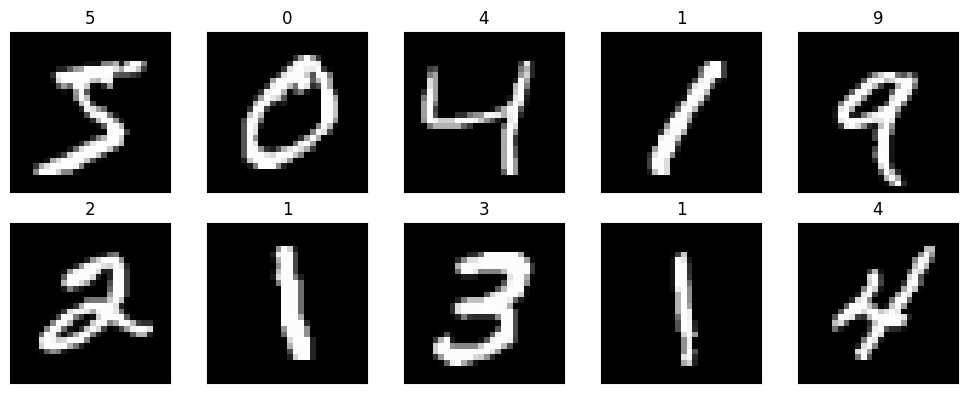

In [3]:
digits = [str(n) for n in range(10)]

plt.figure(figsize=(10, 4))

for n in range(10):
    ax = plt.subplot(2, 5, n + 1)
    ax.imshow(train_x[n].squeeze(), cmap="gray")
    ax.set_title(digits[np.argmax(train_y[n])])
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


In [4]:
input_shape = (28, 28, 1)

inputs = Input(shape=input_shape)

x = Conv2D(32, 3, activation="relu")(inputs)
x = MaxPooling2D(2)(x)
x = BatchNormalization()(x)

x = Conv2D(64, 3, activation="relu")(x)
x = MaxPooling2D(2)(x)
x = BatchNormalization()(x)

x = Flatten()(x)

x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.1)(x)

outputs = Dense(10, activation="softmax")(x)

cnn_model = Model(inputs=inputs, outputs=outputs)

cnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,034 (910.29 KB)

 Trainable params: 232,842 (909.54 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
optimizer = RMSprop(learning_rate=0.001)

cnn_model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [6]:
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_delta=0.0001,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

best_path = "best_mnist_model.keras"

save_best = ModelCheckpoint(
    best_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [7]:
history = cnn_model.fit(
    train_x,
    train_y,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler, save_best],
    shuffle=True
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8560 - loss: 0.4534
Epoch 1: val_accuracy improved from None to 0.50517, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - accuracy: 0.9282 - loss: 0.2321 - val_accuracy: 0.5052 - val_loss: 1.6319 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9705 - loss: 0.0996
Epoch 2: val_accuracy improved from 0.50517 to 0.98700, saving model to best_mnist_model.keras

Epoch 2: finished saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 148ms/step - accuracy: 0.9729 - loss: 0.0934 - val_accuracy: 0.9870 - val_loss: 0.0414 - learning_rate: 0.0010
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9797 - loss: 0.0716
Epoch 3: val_accuracy improved from 0.98700 to 0.98767, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_mode

In [8]:
loss_value, accuracy_value = cnn_model.evaluate(
    test_x,
    test_y,
    verbose=2
)

print("Test Loss:", loss_value)
print("Test Accuracy:", accuracy_value)
print("Test Accuracy %:", accuracy_value * 100)


313/313 - 3s - 10ms/step - accuracy: 0.9906 - loss: 0.0309
Test Loss: 0.030943581834435463
Test Accuracy: 0.9905999898910522
Test Accuracy %: 99.05999898910522


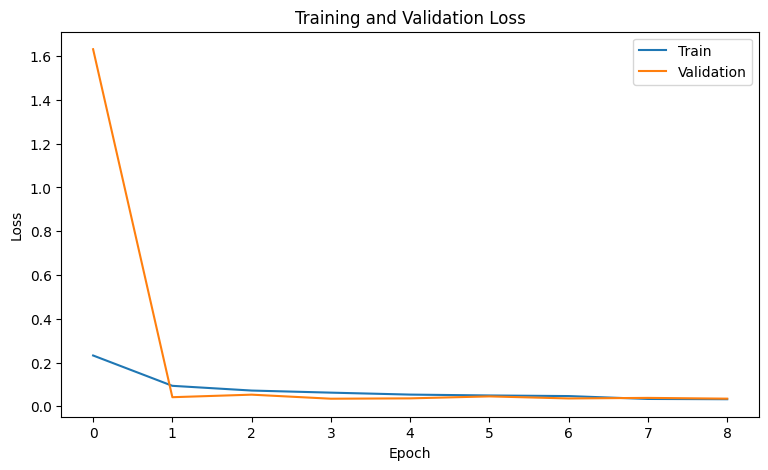

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


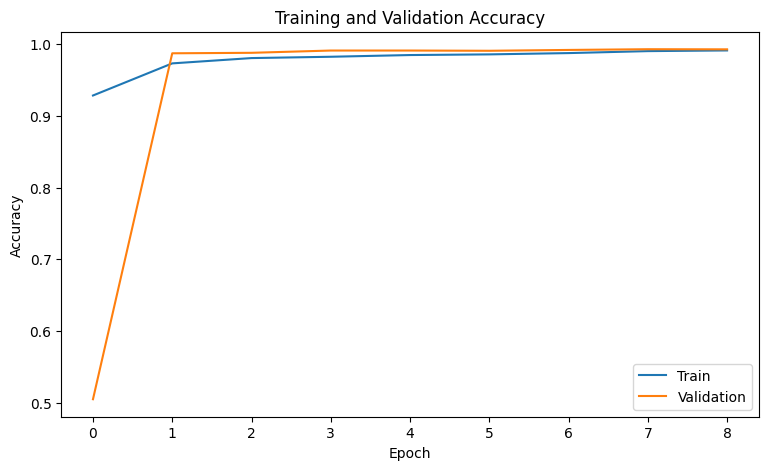

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [11]:
probabilities = cnn_model.predict(test_x)

predicted_labels = np.argmax(probabilities, axis=1)
actual_labels = np.argmax(test_y, axis=1)

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=digits
    )
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix:
[[ 973    0    1    0    0    0    3    2    1    0]
 [   0 1132    1    0    0    0    0    1    1    0]
 [   2    1 1024    0    0    0    0    3    2    0]
 [   0    0    2 1002    0    2    0    2    1    1]
 [   0    0    0    0  979    0    0    0    1    2]
 [   0    0    0    6    0  879    3    1    2    1]
 [   3    3    1    0    1    1  948    0    1    0]
 [   0    3    2    0    0    0    0 1021    1    1]
 [   1    0    2    1    1    0    0    1  966    2]
 [   0    3    0    1    7    4    0    6    6  982]]


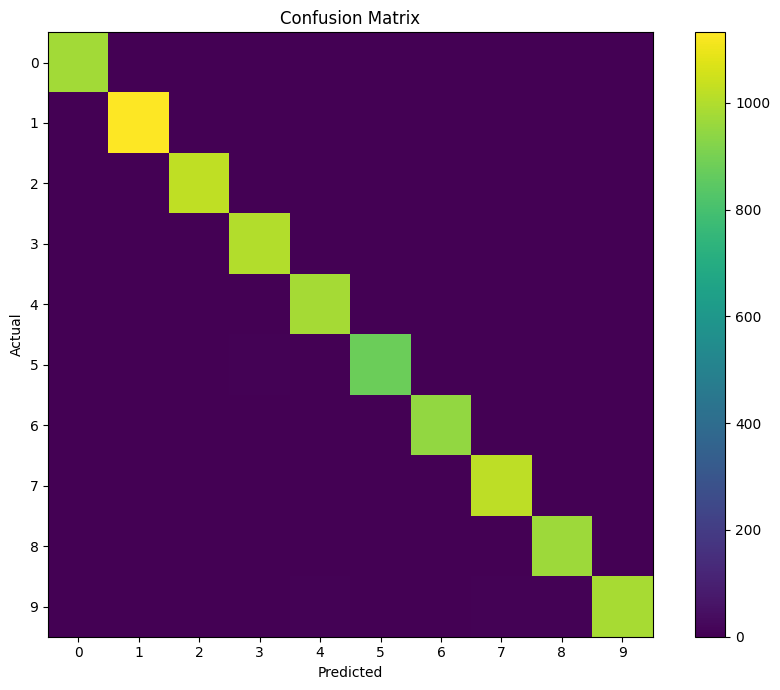

In [12]:
matrix = confusion_matrix(actual_labels, predicted_labels)

print("Confusion Matrix:")
print(matrix)

plt.figure(figsize=(9, 7))
plt.imshow(matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(10), digits)
plt.yticks(range(10), digits)
plt.colorbar()

plt.tight_layout()
plt.show()


In [13]:
balanced_acc = balanced_accuracy_score(
    actual_labels,
    predicted_labels
)

ber_value = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber_value)

cnn_model.save("mnist_cnn_final.keras")


Balanced Accuracy: 0.9904691788402646
BER: 0.009530821159735359


In [14]:
best_model = keras.models.load_model(best_path)

best_loss, best_accuracy = best_model.evaluate(
    test_x,
    test_y,
    verbose=2
)

print("Best Model Test Loss:", best_loss)
print("Best Model Test Accuracy:", best_accuracy)
print("Best Model Test Accuracy %:", best_accuracy * 100)


313/313 - 4s - 11ms/step - accuracy: 0.9930 - loss: 0.0278
Best Model Test Loss: 0.02783229388296604
Best Model Test Accuracy: 0.9929999709129333
Best Model Test Accuracy %: 99.29999709129333


In [15]:
best_probabilities = best_model.predict(test_x)

best_predictions = np.argmax(best_probabilities, axis=1)
true_values = np.argmax(test_y, axis=1)

print(
    classification_report(
        true_values,
        best_predictions,
        target_names=digits
    )
)

best_cm = confusion_matrix(true_values, best_predictions)

print("Confusion Matrix:")
print(best_cm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Confusion Matrix:
[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1130    1    0    0    1    0    3    0    0]
 [   1    0 1025    0    0    0    0    6    0    0]
 [   0    0    0 1003 

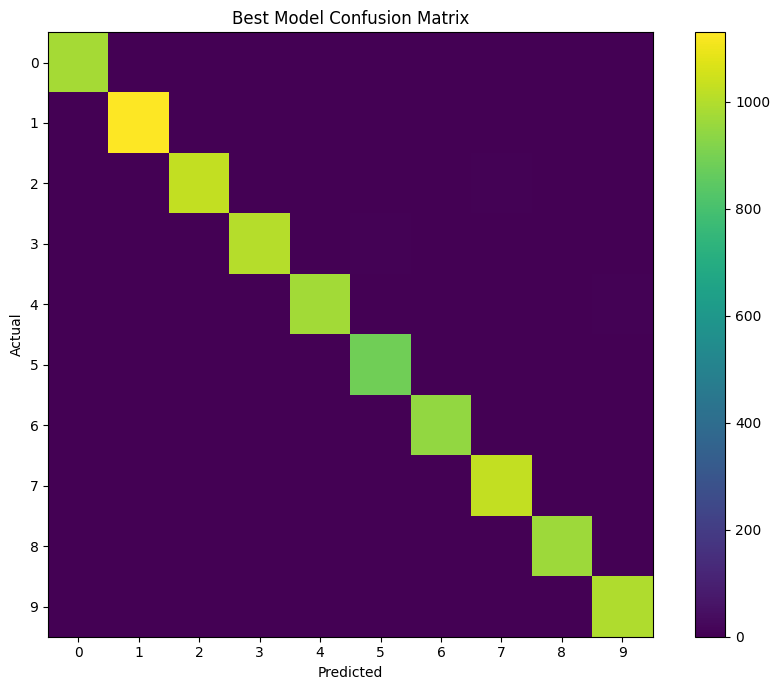

In [16]:
plt.figure(figsize=(9, 7))
plt.imshow(best_cm)

plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(10), digits)
plt.yticks(range(10), digits)
plt.colorbar()

plt.tight_layout()
plt.show()


In [17]:
final_balanced_accuracy = balanced_accuracy_score(
    true_values,
    best_predictions
)

final_ber = 1 - final_balanced_accuracy

print("Balanced Accuracy:", final_balanced_accuracy)
print("BER:", final_ber)


Balanced Accuracy: 0.9929469023009855
BER: 0.007053097699014521


In [18]:
first_conv = next(
    layer for layer in best_model.layers
    if isinstance(layer, Conv2D)
)

print("First convolution layer:", first_conv.name)

weights = first_conv.get_weights()[0]

print("Filter shape:", weights.shape)


First convolution layer: conv2d
Filter shape: (3, 3, 1, 32)


In [19]:
normalizer = MinMaxScaler()

normalized_weights = normalizer.fit_transform(
    weights.reshape(-1, 1)
).reshape(weights.shape)


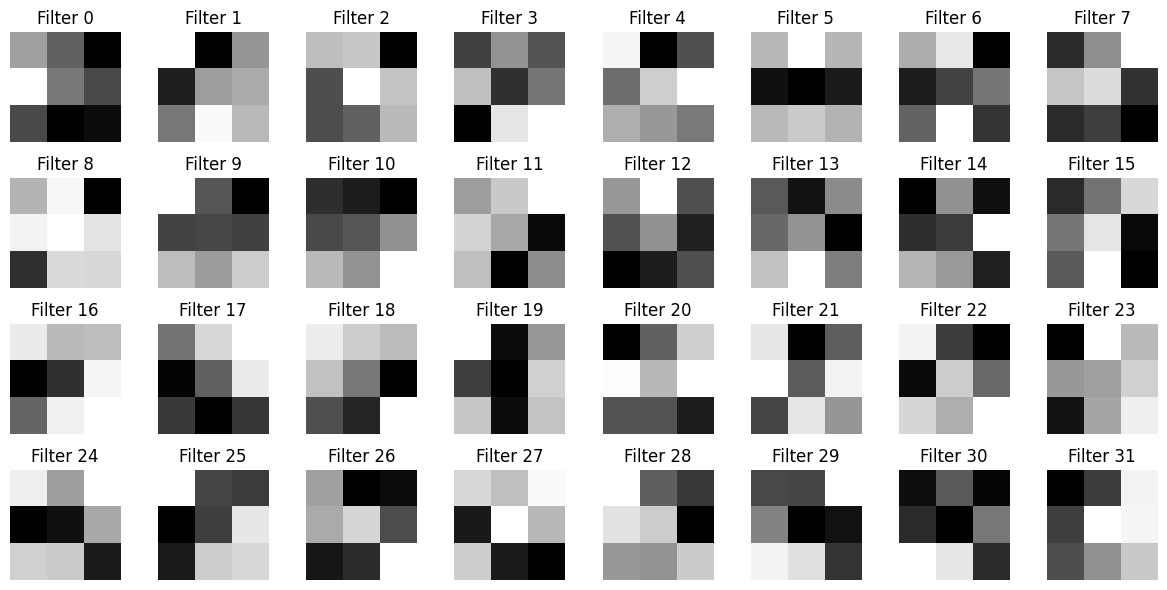

In [20]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for filter_index in range(normalized_weights.shape[-1]):
    kernel = normalized_weights[:, :, 0, filter_index]

    axes[filter_index].imshow(kernel, cmap="gray")
    axes[filter_index].set_title(f"Filter {filter_index}")
    axes[filter_index].axis("off")

plt.tight_layout()
plt.show()


In [21]:
print("========== FINAL RESULTS ==========")
print(f"Test Accuracy: {best_accuracy * 100:.2f}%")
print(f"Balanced Accuracy: {final_balanced_accuracy * 100:.2f}%")
print(f"BER: {final_ber:.4f}")


========== FINAL RESULTS ==========
Test Accuracy: 99.30%
Balanced Accuracy: 99.29%
BER: 0.0071
